## Credict Card Fraud Prediction.

* La industria financiera enfrenta una evolución constante en las tácticas de ciberataques, lo que exige sistemas de defensa cada vez más sofisticados. Este proyecto desarrolla un ecosistema de detección proactiva mediante Machine Learning, optimizado para identificar patrones transaccionales anómalos en tiempo real. El objetivo principal es mitigar riesgos financieros mediante un algoritmo capaz de aprender de datos históricos, logrando un equilibrio crítico: maximizar la detección de fraude reduciendo al mínimo la fricción para el cliente legítimo.

## Significado de Variables

* Transdatetrans_time = Transaction Date Time
* Merchant = Merchant Name
* Category = Category of Merchant
* amt = Amount of Transaction
* city = City of Credit Card Holder
* State = State of Credit Card Holder
* lat = Latitude Location of Purchase
* Long = Longitude Location of Purchase
* City_pop = Credict Card Holder's City Population
* job = Job od credict card holder
* dob = date of birth of credit card holder
* trans_num = Transaction number
* merch_lat = latitude location of merchant
* merch_long = longitude location of merchant
* is_fraud = cuando la transaccion es fraude es 1 y cuando no es 0

## importacion de dependencias

In [42]:
import pandas as pd
from sklearn.compose import ColumnTransformer
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from sklearn.preprocessing import LabelEncoder

In [43]:
df = pd.read_csv(r'C:\Users\jabes\Desktop\PORTAFOLIO CIENTIFICO DE DATOS\FRAUDE\credit_card_frauds.csv')
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


## EDA

In [44]:
print(f'Shape DF: {df.shape}')
print('=*'*30)
print(f'NaN : {df.isna().sum()}')

Shape DF: (339607, 15)
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
NaN : trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

is_fraud
0    99.475276
1     0.524724
Name: proportion, dtype: float64
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Conteo de las clasesis_fraud
0    337825
1      1782
Name: count, dtype: int64


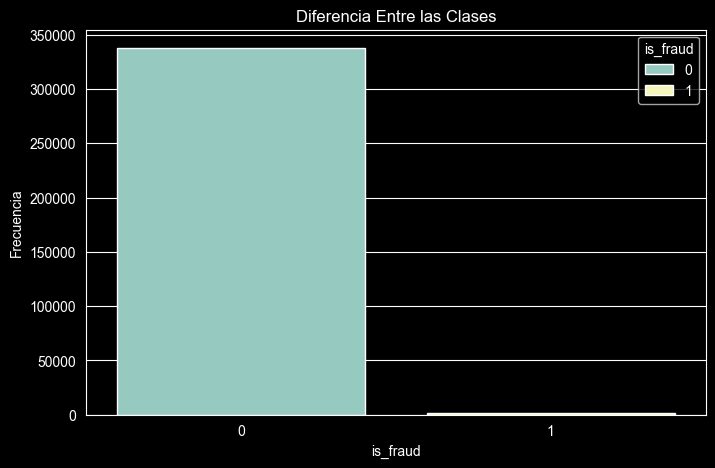

In [46]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='is_fraud', hue='is_fraud')
plt.title('Diferencia Entre las Clases')
plt.xlabel('is_fraud')
plt.ylabel('Frecuencia')
print(df['is_fraud'].value_counts(normalize=True)*100)
print('=*'*30)
print(f'Conteo de las clases{df['is_fraud'].value_counts()}')
plt.show()

* Se observa un desbalance notable en la variable is Fraud, indicando que las transacciones buenas son mayores que las malas.

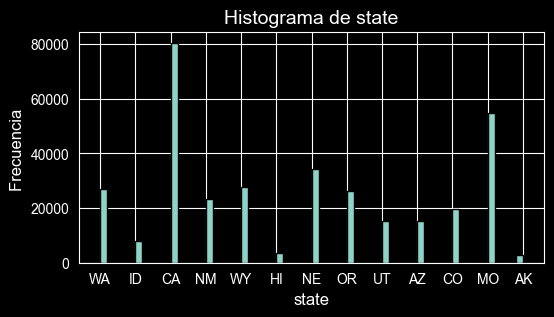

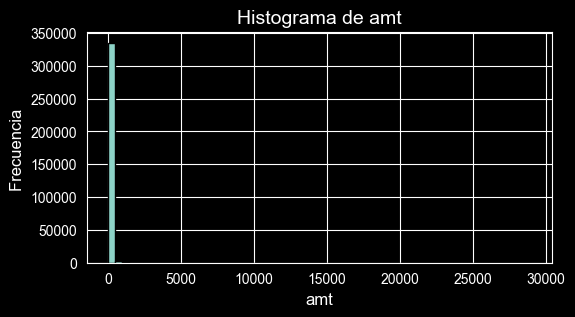

In [47]:
columns=df[['state','amt']]
for col in columns:
    plt.figure(figsize=(6,3))
    plt.hist(df[col], bins=60, edgecolor='black')
    plt.title(f"Histograma de {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frecuencia ", fontsize=12)
    plt.show()

In [48]:
def describe_modif(df):
    num_df = df.select_dtypes(include='number')
    desc = num_df.describe()
    desc.loc['count ceros'] = (num_df == 0).sum()
    desc.loc['count negativos'] = (num_df < 0).sum()
    desc.loc['count null'] = num_df.isna().sum()
    desc.loc['pct ceros'] = (num_df == 0).mean()
    desc.loc['pct negativos'] = (num_df < 0).mean()
    desc.loc['pct nulls'] = num_df.isna().mean()
    desc.loc['Coef. Variacion'] = desc.loc['std'] / desc.loc['mean']
    q1 = desc.loc['25%']
    q3 = desc.loc['75%']
    iqr = q3 - q1
    desc.loc['IQR'] = iqr
    outliers = ((num_df < (q1 - 1.5 * iqr))|(num_df > (q3 + 1.5 * iqr))).sum()
    desc.loc['Conteo de Outliers'] = outliers
    desc.loc['Asimetria'] = num_df.skew()
    percentiles = [0, 0.25,0.50,0.60, 0.80, 0.96,0.97, 0.98, 0.99,1]
    for p in percentiles:
        desc.loc[f'P{int(p*100)}'] = num_df.quantile(p)
    desc = desc.drop(index=['min','25%','50%','75%', 'max'])
    return desc.round(2)


describe_modif(df)

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,339607.00,339607.00,339607.00,339607.00,339607.00,339607.00,339607.00
mean,70.58,39.72,-110.62,107140.87,39.72,-110.62,0.01
std,161.68,5.09,12.65,293029.89,5.13,12.66,0.07
count ceros,0.00,0.00,0.00,0.00,0.00,0.00,337825.00
count negativos,0.00,0.00,339607.00,0.00,0.00,339607.00,0.00
count null,0.00,0.00,0.00,0.00,0.00,0.00,0.00
pct ceros,0.00,0.00,0.00,0.00,0.00,0.00,0.99
pct negativos,0.00,0.00,1.00,0.00,0.00,1.00,0.00
pct nulls,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Coef. Variacion,2.29,0.13,-0.11,2.73,0.13,-0.11,13.77


* Tras ejecutar la función personalizada describe_modif, se determinó que la variable amt presenta una dispersión extrema con montos desde $1.00 hasta $28,948.90; con un Coeficiente de Variación de 2.29 y una asimetría de 40.30, se decidió mantener los outliers para evitar sesgar el dataset y no perder la señal crítica de los fraudes de alto impacto. En cuanto al perfil demográfico (age), la población es mayoritariamente madura con una media de 53.5 años y una desviación estándar de 17.04, donde el 25% supera los 68 años, sugiriendo un segmento que requiere esquemas de seguridad reforzados. Al no existir abundancia de variables descriptivas iniciales, el valor del análisis reside en el Feature Engineering, donde indicadores como far_night_flag (89% ceros) y hora_extrema (73% ceros) permitirán identificar patrones anómalos. Finalmente, el fuerte desbalance en la variable objetivo is_fraud (99% de transacciones legítimas) confirma que el éxito del modelo no dependerá del Accuracy, sino de su capacidad para separar clases mediante métricas de precisión y sensibilidad (PR AUC) en los casos de comportamiento atípico.

## Feature Engeniering

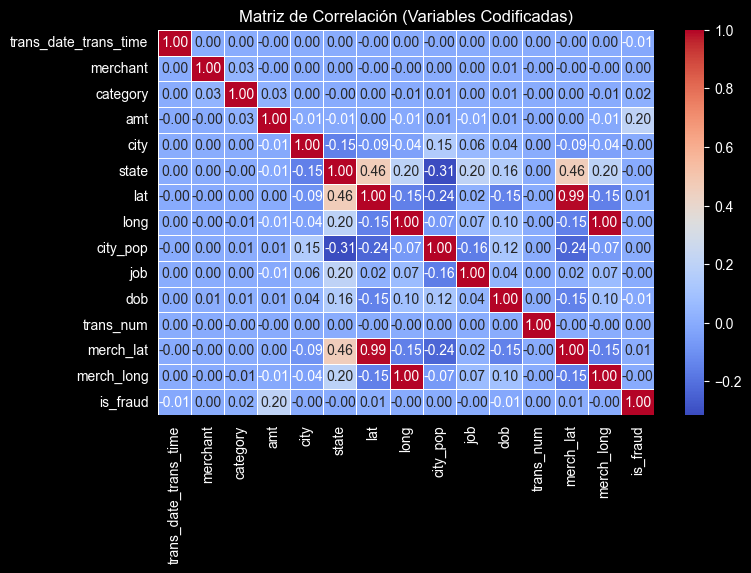

In [49]:


df_corr = df.copy()
if 'trans_date' in df_corr.columns:
    df_corr['trans_date'] = pd.to_datetime(df_corr['trans_date']).apply(lambda x: x.toordinal())
if 'trans_time' in df_corr.columns:
    df_corr['trans_time'] = df_corr['trans_time'].apply(lambda x: x.hour * 3600 + x.minute * 60 + x.second)
# ENCODING
le = LabelEncoder()
columnas_texto = df_corr.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# MATRIZ DE CORRELACION
corr_matrix = df_corr.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5)
plt.title('Matriz de Correlación (Variables Codificadas)')
plt.show()

In [50]:
#Transforme la variable dob a la edad real de cada ciudadano
df['dob'] = pd.to_datetime(df['dob'])
hoy = date.today()
df['age'] = df['dob'].apply(
    lambda x: hoy.year - x.year - ((hoy.month, hoy.day) < (x.month, x.day)))
columna_a_mover = df.pop('age')
df.insert(12, 'age', columna_a_mover)

# SEPARANDO TRANSDATE DE TRANS TIME
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_time'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
columna_a_mover = df.pop('trans_time')
df.insert(1, 'trans_time', columna_a_mover)

# SEPARANDO EL DATE
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_date'] = df['trans_date_trans_time'].dt.date
columna_a_mover = df.pop('trans_date')
df.insert(0, 'trans_date', columna_a_mover)

# Creando Nueva variable distance_km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long']).round(2)


df['far_night_flag'] = (
    (df['distance_km'] > 80) &
    ((df['trans_time'] >= 0) & (df['trans_time'] <= 6))
).astype(int)

In [51]:
df.drop(columns=['trans_date_trans_time','long','lat','merch_long','merch_lat','trans_num','merchant','dob'], inplace=True)

In [52]:
df.groupby('far_night_flag')['is_fraud'].mean()*100

far_night_flag
0    0.489368
1    0.819604
Name: is_fraud, dtype: float64

- La variable **is_fraud** presenta una correlación leve con **amt**, lo que sugiere que ciertos montos pueden desviarse del comportamiento transaccional habitual de los clientes. Aunque la relación no es fuerte, este patrón puede aportar valor combinado con otras variables.

- La relación observada entre **dob** y **trans_time** se considera espuria (no significativa). Aunque podría inferirse una posible conexión con fechas de cumpleaños, al tratarse de la fecha de nacimiento y no de un evento recurrente, esta variable carece de utilidad predictiva en este contexto y será descartada.

- Se identifica una fuerte dependencia entre **job** y **state**, lo cual refleja la concentración geográfica de ciertas profesiones. En consecuencia, estas variables aportan valor en la segmentación del comportamiento del cliente. Las principales señales consideradas para el modelo serán: **amt**, **age**, **state** y **job**.

- Se incorporó la variable **distance_km**, calculada mediante la fórmula de Haversine, con el objetivo de medir la distancia geográfica entre la ubicación del cliente y el lugar donde se realiza la transacción. Esta variable permite detectar posibles anomalías espaciales.

- se incorporo la variable **far_night_flag**, esta me ayudara a validar las transacciones que pasan de noche en horarios de anomalia. La variable muestra una mayor incidencia de fraude en transacciones que cumplen la condición definida, con un incremento relativo aproximado del 67%, lo que sugiere que captura patrones anómalos de comportamiento.


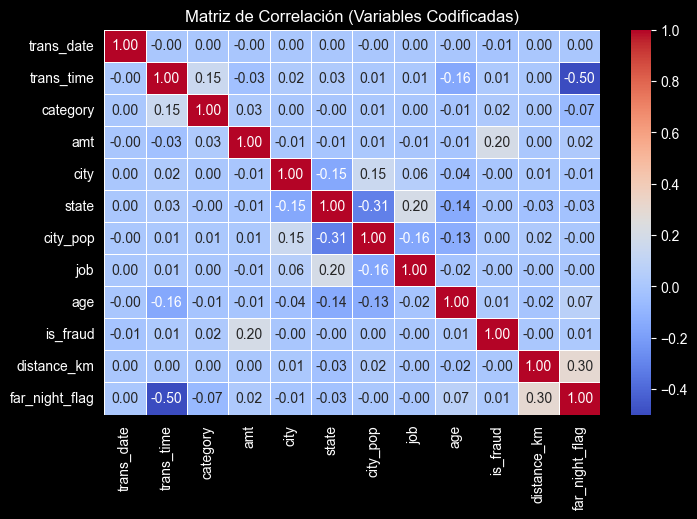

In [53]:
df_corr_t = df.copy()
columnas_texto = df_corr_t.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df_corr_t[col] = le.fit_transform(df_corr_t[col].astype(str))

# MATRIZ DE CORRELACION
corr_matrix = df_corr_t.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5)
plt.title('Matriz de Correlación (Variables Codificadas)')
plt.show()

## Análisis de Correlación y Diagnóstico de Variables
Tras la reducción de dimensionalidad y la depuración de características colineales que introducían ruido estadístico, la matriz de correlación revela una topología de datos altamente limpia y predictiva. El análisis del espacio de variables arroja los siguientes hallazgos críticos para la arquitectura del modelo:

* Sinergia Categórico-Temporal (category y trans_time): Destaca una fuerte interacción entre la categoría del comercio y la hora de la transacción. Esta correlación confirma empíricamente que los usuarios legítimos mantienen patrones transaccionales ligados a ventanas horarias específicas según la naturaleza del servicio. Esta "huella de comportamiento" proporciona al estimador una línea base (baseline) excepcionalmente robusta para aislar desviaciones anómalas.

* Poder Discriminante del Comportamiento Nocturno (far_night_flag): La variable sintética de horario nocturno exhibe una correlación inversa altamente conveniente respecto a la volumetría transaccional estándar. Este comportamiento matemático valida la hipótesis de negocio: las ventanas de madrugada concentran una densidad desproporcionada de vectores de ataque. En consecuencia, esta variable se perfila como un discriminador de fraude de primera línea.

* Robustez del Monto Transaccional (amt) y Eficacia del Feature Engineering (edad): Se ratifica la alta dependencia lineal entre el monto de la operación (amt) y el evento de fraude (is_fraud), consolidando el volumen económico como un ancla predictiva del modelo. Finalmente, la variable demográfica edad presenta una correlación inversa (baja colinealidad) frente a los factores transaccionales. Este aislamiento estadístico es un indicador de éxito de la fase de Feature Engineering, demostrando que esta variable inyecta una señal diferenciada y ortogonal que facilitará una segmentación de perfiles de riesgo mucho más granular.

## Analisis Bivariado de Variables con Mejor Correlacion.

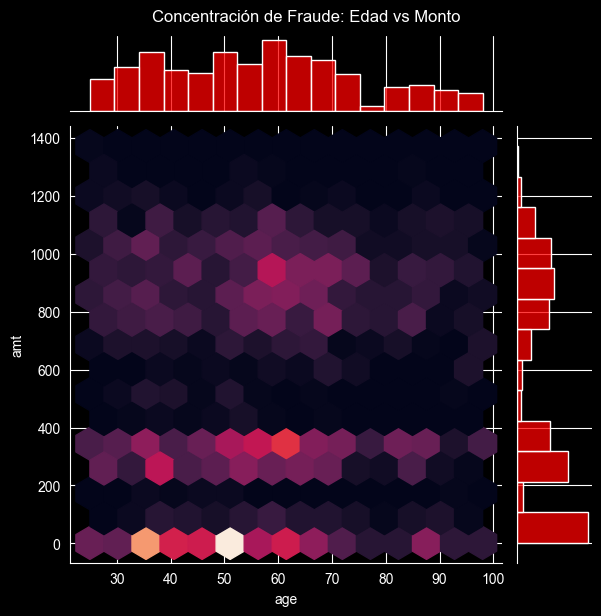

In [54]:
# Solo los casos de fraude
fraude_df = df[df['is_fraud'] == 1]
sns.jointplot(data=fraude_df, x='age', y='amt', kind='hex', joint_kws=dict(cmap='rocket'),color="red")
plt.suptitle('Concentración de Fraude: Edad vs Monto', y=1.02)
plt.show()

* Se observa que, conforme aumenta la edad del titular, existe una tendencia hacia la realización de gastos de mayor cuantía, osea una mejor capacidad transaccional. tambien este es un indicador de riezgo porque los ciberdelincuentes podrian estar aprovechando esto para realizar el fraude.

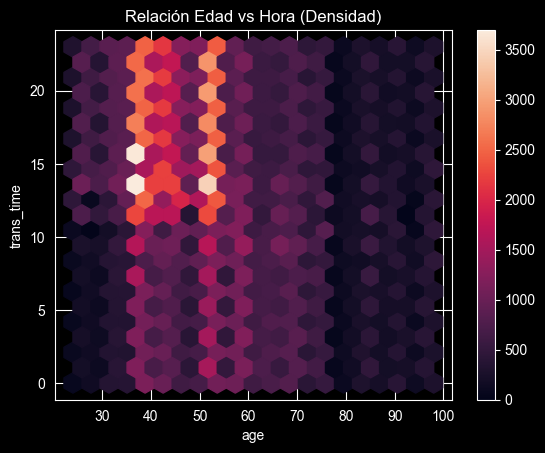

In [55]:
df.plot.hexbin(y='trans_time',x='age', gridsize=20, cmap='rocket', sharex=False)
plt.title('Relación Edad vs Hora (Densidad)')
plt.show()

* El grafico revela una concentración de actividad en los extremos de la jornada (madrugada y noche cerrada). Este patrón es particularmente relevante para la segmentación de fraude: mientras que en usuarios jóvenes podría reflejar hábitos de consumo nocturno, en segmentos de mayor edad estas transacciones en horas de "baja vigilancia" actúan como un fuerte indicador de anomalía.

* este hallazgo me lleva a crear otra variable llamada hora_extrema, que clasificara las transacciones realizadas de las 22:00 a las 4:00 Horas como transacciones fuera de horario y les dara un flag.

In [56]:
df['hora_extrema'] = df['trans_time'].apply(lambda x: 1 if x >= 22 or x <= 4 else 0)
df.drop(columns=['trans_date'], inplace=True)

In [57]:
df.head(2)

,trans_time,category,amt,city,state,city_pop,job,age,is_fraud,distance_km,far_night_flag,hora_extrema
0,0,grocery_pos,107.23,Orient,WA,149,Special educational needs teacher,47,0,30.21,0,1
1,0,entertainment,220.11,Malad City,ID,4154,Nature conservation officer,64,0,108.21,1,1


## **Iniciando Preparacion para Modelo Predictivo.**

# Separacion de los Datos (Train/test)

In [58]:
from sklearn.model_selection import train_test_split, GridSearchCV

x = df.drop('is_fraud', axis=1)
y= df['is_fraud']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, shuffle=True, stratify=y)

* Debido a las limitaciones del dataset, no fue posible realizar una validacion out-of-time, sin embargo , se implementaron buenas practicas para la separacion de los datos y se utilizaran metricas robuscas para la evaluacion.

* Se validó la ausencia de data leakage asegurando que todas las transformaciones (encoding, feature engineering y scaling) fueron ajustadas únicamente sobre el conjunto de entrenamiento y posteriormente aplicadas al conjunto de prueba. ## Data Leakage Validation. Se aseguró que todas las transformaciones fueron ajustadas únicamente sobre el conjunto de entrenamiento mediante el uso de pipelines, evitando fuga de información hacia el conjunto de prueba.

## Pipeline Target Encoding + GridSearch

In [59]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')
import xgboost as xgb
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer

# Definición de columnas
var_target   = ['city', 'state', 'category', 'job']
all_numeric  = x_train.select_dtypes(include=['number']).columns.tolist()  # ← línea que faltaba
numeric_cols = [col for col in all_numeric if col not in var_target]

# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cols=var_target), var_target),
        ('keep_num',   'passthrough',                  numeric_cols)
    ],
    remainder='drop'
)

#  Pipeline
f_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        eval_metric='aucpr',
        tree_method='hist',
        device='cuda'
    ))
])

# GridSearch
param_grid = {
    'classifier__max_depth':        [3, 5, 6],
    'classifier__learning_rate':    [0.01, 0.05],
    'classifier__n_estimators':     [100, 200, 300],
    'classifier__subsample':        [0.4, 0.9],
    'classifier__colsample_bytree': [0.4, 0.9],
    'classifier__min_child_weight': [5, 30]
}

grid_search = GridSearchCV(
    f_pipe,
    param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=1,
    verbose=1
)

grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__colsample_bytree': [0.4, 0.9], 'classifier__learning_rate': [0.01, 0.05], 'classifier__max_depth': [3, 5, ...], 'classifier__min_child_weight': [5, 30], ...}"
,scoring,'average_precision'
,n_jobs,1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('target_enc', ...), ('keep_num', ...)]"


In [60]:
# Resultados
print(f'\n Mejores Parámetros: {grid_search.best_params_}')
print(f"\nMejor Score (PR AUC): {grid_search.best_score_:.4f}")


 Mejores Parámetros: {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 300, 'classifier__subsample': 0.9}

Mejor Score (PR AUC): 0.8759


* luego de utilizar GridSearch para buscar los mejores parametros para el modelo, pasaremos a buscar los mejores Hiperparametros con Optuna + XGB, esto nos dara una busqueda mas ampliada de lo que inicio el GridSearch.

## Primera Aproximacion (Params GridSearch).

In [61]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

def objective(trial):
    max_d = trial.suggest_int("max_depth", 6, 8)
    max_leaves_limit = min(255, 2**max_d)

    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 900),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "max_depth":         max_d,
        "grow_policy":       "lossguide",
        "max_leaves":        trial.suggest_int("max_leaves", 8, max_leaves_limit),
        "subsample":         trial.suggest_float("subsample", 0.5, 0.9),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "min_child_weight":  trial.suggest_int("min_child_weight", 5,30),
        "reg_alpha":         trial.suggest_float("reg_alpha", 2, 6, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 6, log=True),
        "gamma":             trial.suggest_float("gamma", 1e-3, 5, log=True),
        "random_state":      42,
        "device":            "cuda",
        "tree_method":       "hist",
        "eval_metric":       "aucpr",
        "verbosity":         0
    }

    # Model
    model = xgb.XGBClassifier(**params)

    # Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Validacion cv
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Metrica de Evaluacion
    scores = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=cv,
        scoring='average_precision',
        n_jobs=1
    )

    return scores.mean()

# --- Ejecución del Estudio ---
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150)

[I 2026-04-15 22:27:15,691] A new study created in memory with name: no-name-094c87e2-1798-48dd-bfe0-625e66badc32
[I 2026-04-15 22:27:33,970] Trial 0 finished with value: 0.766666585454324 and parameters: {'max_depth': 7, 'n_estimators': 717, 'learning_rate': 0.0050096191646493244, 'max_leaves': 43, 'subsample': 0.6787116008812549, 'colsample_bytree': 0.699298240999528, 'min_child_weight': 15, 'reg_alpha': 2.188942426572872, 'reg_lambda': 0.0011176622288641713, 'gamma': 0.05703240794476913}. Best is trial 0 with value: 0.766666585454324.
[I 2026-04-15 22:27:45,782] Trial 1 finished with value: 0.8147559032912326 and parameters: {'max_depth': 7, 'n_estimators': 512, 'learning_rate': 0.030249484916928207, 'max_leaves': 62, 'subsample': 0.7792797355986925, 'colsample_bytree': 0.8172612962128926, 'min_child_weight': 30, 'reg_alpha': 2.0794559707160785, 'reg_lambda': 0.07875351972593683, 'gamma': 0.0018740201541228908}. Best is trial 1 with value: 0.8147559032912326.
[I 2026-04-15 22:27:57,

In [62]:
print(f"Mejor score PR AUC: {study.best_value:.4f}")
print(f"Mejores parámetros: {study.best_params}")

Mejor score PR AUC: 0.8893
Mejores parámetros: {'max_depth': 8, 'n_estimators': 832, 'learning_rate': 0.04025434240815862, 'max_leaves': 251, 'subsample': 0.899801569924748, 'colsample_bytree': 0.7639678658788739, 'min_child_weight': 5, 'reg_alpha': 2.699029352778989, 'reg_lambda': 0.009047013673410651, 'gamma': 0.0012073280998978135}


Entrenando modelo final...


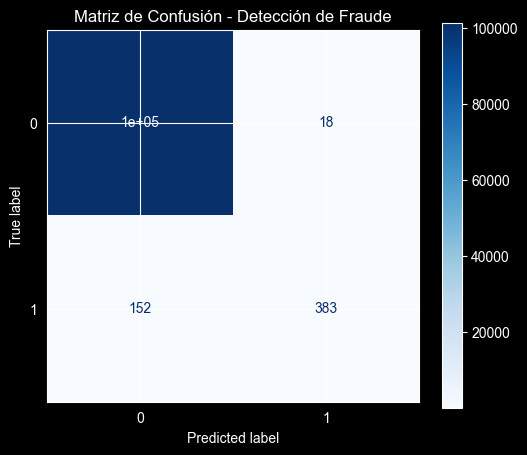


Resultados Finales:


,Model,PR AUC (Test),PR AUC (Train),ROC AUC,F1-Score,Recall,Precision,KS,Threshold,TP,FP,FN,TN,Diff (Train-Test)
0,XGB + Optuna,0.876,0.9851,0.9941,0.8184,0.7159,0.9551,0.9304,0.6,383,18,152,101330,0.1091


In [68]:
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from scipy.stats import ks_2samp


# parámetros de Optuna

best_params = study.best_params.copy()
best_params["random_state"] = 42
best_params["device"] = "cuda"
best_params["tree_method"] = "hist"
best_params["eval_metric"] = "aucpr"

#MODELO
final_model_xgb = xgb.XGBClassifier(**best_params)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_model_xgb)
])

print("Entrenando modelo final...")
final_pipeline.fit(x_train, y_train)


# PROBS

y_test_proba = final_pipeline.predict_proba(x_test)[:, 1]
y_train_proba = final_pipeline.predict_proba(x_train)[:, 1]


# Threshold tuning

thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_temp = (y_test_proba > t).astype(int)

    precision = precision_score(y_test, y_pred_temp, zero_division=0)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)

    threshold_results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=['threshold', 'precision', 'recall', 'f1']
)

# threshold
threshold = 0.6

# Pred fcon threshold
y_test_pred = (y_test_proba > threshold).astype(int)

#  Métricas principales

test_pr_auc = average_precision_score(y_test, y_test_proba)
train_pr_auc = average_precision_score(y_train, y_train_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

diff = train_pr_auc - test_pr_auc


# KS

fraud_probs = y_test_proba[y_test == 1]
nonfraud_probs = y_test_proba[y_test == 0]

ks_stat, ks_pvalue = ks_2samp(fraud_probs, nonfraud_probs)


# Matriz de confusión

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Detección de Fraude')
plt.show()

#RESULTS
results_df = pd.DataFrame({
    "Model": ["XGB + Optuna"],
    "PR AUC (Test)": [round(test_pr_auc, 4)],
    "PR AUC (Train)": [round(train_pr_auc, 4)],
    "ROC AUC": [round(roc_auc, 4)],
    "F1-Score": [round(f1, 4)],
    "Recall": [round(recall, 4)],
    "Precision": [round(precision, 4)],
    "KS": [round(ks_stat, 4)],
    "Threshold": [threshold],
    "TP": [tp],
    "FP": [fp],
    "FN": [fn],
    "TN": [tn],
    "Diff (Train-Test)": [round(diff, 4)]
})

print("\nResultados Finales:")
results_df

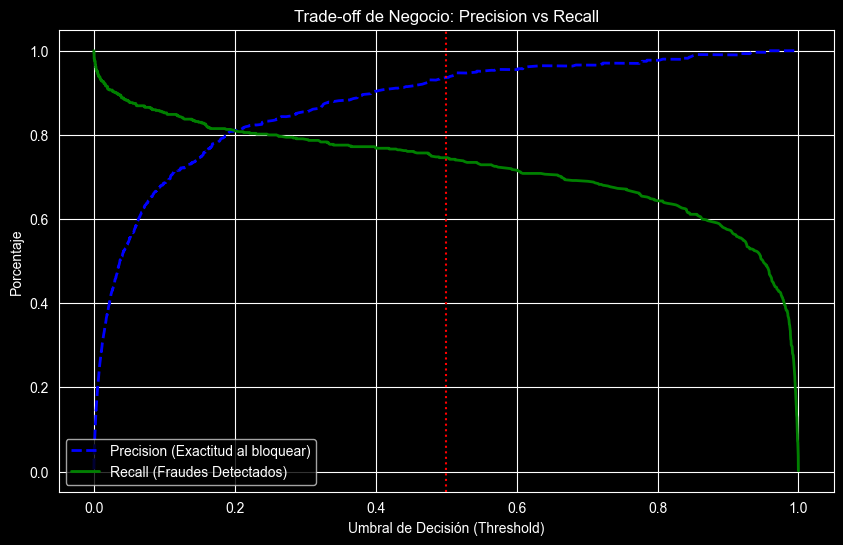

--- 💼 Simulador de Impacto en Negocio ---

🔹 Umbral de decisión: 0.15
  🚨 Fraudes Detectados: 444 (Recall: 83.0%)
  ❌ Fraudes que se escapan: 91
  ⚠️ Falsas Alarmas (Fricción a clientes): 151

🔹 Umbral de decisión: 0.2
  🚨 Fraudes Detectados: 433 (Recall: 80.9%)
  ❌ Fraudes que se escapan: 102
  ⚠️ Falsas Alarmas (Fricción a clientes): 101

🔹 Umbral de decisión: 0.3
  🚨 Fraudes Detectados: 422 (Recall: 78.9%)
  ❌ Fraudes que se escapan: 113
  ⚠️ Falsas Alarmas (Fricción a clientes): 72

🔹 Umbral de decisión: 0.4
  🚨 Fraudes Detectados: 411 (Recall: 76.8%)
  ❌ Fraudes que se escapan: 124
  ⚠️ Falsas Alarmas (Fricción a clientes): 44

🔹 Umbral de decisión: 0.5
  🚨 Fraudes Detectados: 399 (Recall: 74.6%)
  ❌ Fraudes que se escapan: 136
  ⚠️ Falsas Alarmas (Fricción a clientes): 27

🔹 Umbral de decisión: 0.6
  🚨 Fraudes Detectados: 383 (Recall: 71.6%)
  ❌ Fraudes que se escapan: 152
  ⚠️ Falsas Alarmas (Fricción a clientes): 18


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix

# 1. Asegurarnos de tener las probabilidades
# (Usamos y_test_proba que generaste en el bloque anterior)
# y_test_proba = final_pipeline.predict_proba(x_test)[:, 1]

# 2. Calcular Precision y Recall para todos los umbrales
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba)

# 3. Graficar el Trade-off (Ideal para presentar a negocio)
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision (Exactitud al bloquear)", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall (Fraudes Detectados)", linewidth=2)
plt.xlabel("Umbral de Decisión (Threshold)")
plt.ylabel("Porcentaje")
plt.title("Trade-off de Negocio: Precision vs Recall")
plt.legend(loc="lower left")
plt.grid(True)
plt.axvline(x=0.5, color='r', linestyle=':', label='Umbral Actual (0.5)')
plt.show()

# 4. Simulador de Impacto Directo
umbrales_a_probar = [0.15, 0.20, 0.30, 0.40, 0.50, 0.60]

print("--- 💼 Simulador de Impacto en Negocio ---")
for umbral in umbrales_a_probar:
    # Aplicar el nuevo umbral: Todo lo mayor al umbral se marca como fraude (1)
    pred_simulada = (y_test_proba >= umbral).astype(int)

    # Calcular matriz de confusión
    cm = confusion_matrix(y_test, pred_simulada)
    fraudes_detectados = cm[1][1]
    fraudes_perdidos = cm[1][0]
    falsas_alarmas = cm[0][1]

    # Calcular Recall para mostrarlo
    recall_actual = fraudes_detectados / (fraudes_detectados + fraudes_perdidos)

    print(f"\n🔹 Umbral de decisión: {umbral}")
    print(f"  🚨 Fraudes Detectados: {fraudes_detectados} (Recall: {recall_actual:.1%})")
    print(f"  ❌ Fraudes que se escapan: {fraudes_perdidos}")
    print(f"  ⚠️ Falsas Alarmas (Fricción a clientes): {falsas_alarmas}")

## **SHAP Features**

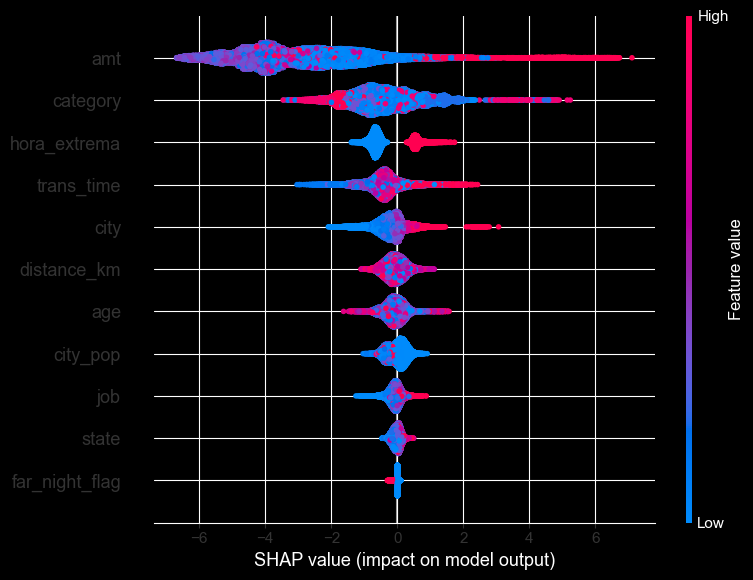

In [70]:
import shap

# Extrae el modelo y transforma x_test por el pipeline
clf        = final_pipeline.named_steps['classifier']
x_test_tr  = final_pipeline.named_steps['preprocessor'].transform(x_test)

# Nombres de columnas en el mismo orden que el ColumnTransformer
feature_names = var_target + numeric_cols

explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(x_test_tr)

shap.summary_plot(shap_values, x_test_tr,
                  feature_names=feature_names, plot_type="dot")

## Conclusion

El modelo desarrollado logró una adecuada capacidad de detección de fraude en un dataset altamente desbalanceado, priorizando el recall para minimizar pérdidas económicas.

Se incorporaron variables contextuales como la distancia geográfica y el horario de la transacción, destacando especialmente la variable `far_night_flag`, la cual mostró un incremento significativo en la incidencia de fraude.

El ajuste del threshold permitió optimizar el balance entre detección de fraude y falsos positivos, alineando el modelo con un escenario real de negocio.

Adicionalmente, el estadístico KS evidenció una buena capacidad de separación entre clases, confirmando la robustez del modelo.

En conjunto, el enfoque demuestra que la detección de fraude depende más de patrones contextuales que de variables individuales, y que la correcta calibración del modelo es clave para su aplicación en entornos reales.